In [1]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
embeddings_s = np.load('../Model/emb_s_all-MiniLM-L6-v2.npy')

description_text_s = pd.read_csv('../Output/london_app_s_tokens.csv')

In [3]:
import ast

description_text_s['tokens'] = description_text_s['tokens'].apply(ast.literal_eval)

print(type(description_text_s['tokens'].iloc[0]))

<class 'list'>


In [4]:
docs_s = description_text_s['tokens'].apply(lambda tokens: ' '.join(tokens)).tolist()

In [5]:
def compute_diversity_score(topic_model):
    """
    Compute topic diversity score as the ratio of unique keywords 
    to total keywords across all topics (excluding topic -1).
    """
    topics_ = topic_model.get_topics()
    all_words = [
        word for topic_id, words in topics_.items() if topic_id != -1
        for word, _ in words
    ]
    unique_words = set(all_words)
    return len(unique_words) / len(all_words) if all_words else 0

In [6]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

def compute_coherence_score(topic_model, docs, top_n_words=10):

    # Tokenize documents
    tokenized_docs = [doc.split() for doc in docs if isinstance(doc, str) and doc.strip()]
    
    # Build gensim dictionary
    dictionary = Dictionary(tokenized_docs)

    # Restrict to words in vectorizer vocabulary
    vectorizer = topic_model.vectorizer_model
    vocab = set(vectorizer.get_feature_names_out())

    topic_words = []
    topic_ids = topic_model.get_topic_info().Topic.tolist()
    for topic_id in topic_ids:
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)[:top_n_words]]
        filtered = [w for w in words if w in vocab and w in dictionary.token2id]
        if filtered:
            topic_words.append(filtered)

    # Compute coherence
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return coherence_model.get_coherence()

In [7]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [8]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

In [9]:
import itertools

param_grid = {
    "n_neighbors": [10, 15, 30],
    "min_dist": [0.0, 0.1, 0.3],
    "min_cluster_size": [10, 15, 30],
    "min_samples": [5, 10, 15],
    "ngram_range": [(1, 1), (1, 2)]
}

# Get all combinations
raw_combinations = list(itertools.product(*param_grid.values()))

# Filter only keep valid combinations where min_samples <= min_cluster_size
valid_combinations = [
    (nn, dist, mcs, ms, ngram)
    for nn, dist, mcs, ms, ngram in raw_combinations
    if ms <= mcs
]

results = []

for nn, dist, mcs, ms, ngram in valid_combinations:

    print(f"Testing: n_neighbors={nn}, min_dist={dist}, min_cluster_size={mcs}, min_samples={ms}, ngram_range={ngram}")

    umap_model = UMAP(
        n_neighbors=nn, 
        n_components=5, 
        min_dist=dist, 
        metric='cosine'
    )
    
    hdbscan_model = HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        prediction_data=True
    )
    
    vectorizer_model = CountVectorizer(ngram_range=ngram)

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        calculate_probabilities=False,
        verbose=False,
        top_n_words=10
    )

    topics, _ = topic_model.fit_transform(docs_s, embeddings=embeddings_s)
    coherence = compute_coherence_score(topic_model, docs_s)
    diversity = compute_diversity_score(topic_model)
    outlier_ratio = sum([1 for t in topics if t == -1]) / len(topics)

    results.append({
        'n_neighbors': nn,
        'min_dist': dist,
        'min_cluster_size': mcs,
        'min_samples': ms,
        'ngram_range': str(ngram),
        'coherence': coherence,
        'diversity': diversity,
        'outlier_ratio': outlier_ratio
    })

Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=10, min_samples=5, ngram_range=(1, 1)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=10, min_samples=5, ngram_range=(1, 2)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=10, min_samples=10, ngram_range=(1, 1)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=10, min_samples=10, ngram_range=(1, 2)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=15, min_samples=5, ngram_range=(1, 1)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=15, min_samples=5, ngram_range=(1, 2)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=15, min_samples=10, ngram_range=(1, 1)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=15, min_samples=10, ngram_range=(1, 2)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=15, min_samples=15, ngram_range=(1, 1)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_size=15, min_samples=15, ngram_range=(1, 2)
Testing: n_neighbors=10, min_dist=0.0, min_cluster_siz

In [10]:
df_results = pd.DataFrame(results)
df_results.to_csv("../Output/Performance (Bertopic).csv", index=False)

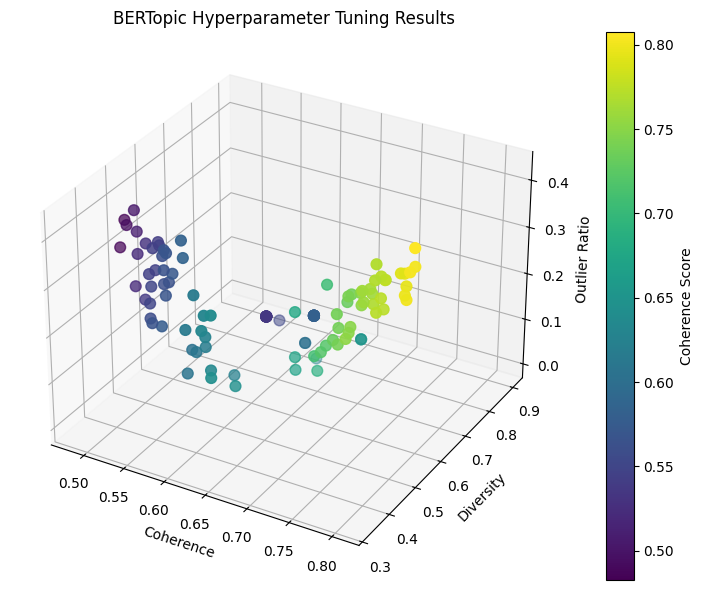

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))

ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df_results['coherence'], df_results['diversity'], df_results['outlier_ratio'],
                c=df_results['coherence'], cmap='viridis', s=60)
ax.set_xlabel('Coherence')
ax.set_ylabel('Diversity')
ax.set_zlabel('Outlier Ratio')

plt.title("BERTopic Hyperparameter Tuning Results")
plt.colorbar(sc, label='Coherence Score')
plt.tight_layout()
plt.show()

In [12]:
import matplotlib.pyplot as plt

def plot_single_hyperparam_effect(df, hyperparam: str):
    """
    Visualize how a single hyperparameter affects key evaluation metrics 
    (coherence, diversity, outlier_ratio) in BERTopic tuning.

    Parameters:
    - df: DataFrame containing tuning results
    - hyperparam: the name of the hyperparameter to analyze (e.g., "min_cluster_size")
    """

    # Group by the hyperparameter and compute mean of each metric
    df_grouped = df.groupby(hyperparam).agg({
        'coherence': 'mean',
        'diversity': 'mean',
        'outlier_ratio': 'mean'
    }).reset_index()

    # Sort for consistent line plot
    df_grouped.sort_values(by=hyperparam, inplace=True)

    # Plot the effect of the hyperparameter on each metric
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df_grouped[hyperparam], df_grouped['coherence'], marker='o', label='Coherence')
    ax.plot(df_grouped[hyperparam], df_grouped['diversity'], marker='o', label='Diversity')
    ax.plot(df_grouped[hyperparam], df_grouped['outlier_ratio'], marker='o', label='Outlier Ratio')

    ax.set_xlabel(hyperparam)
    ax.set_ylabel("Score")
    ax.set_title(f"Effect of '{hyperparam}' on BERTopic Performance")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [45]:
def plot_all_hyperparams(df, metric_names=['coherence', 'diversity', 'outlier_ratio']):
    """
    Plot the effect of each numeric hyperparameter on model metrics

    Parameters:
    - df: tuning results DataFrame
    - metric_names: list of evaluation metrics to exclude from hyperparameter list
    """
    all_columns = df.columns.tolist()
    
    hyperparams = [col for col in all_columns if col not in metric_names + ['ngram_range']]
    numeric_hyperparams = [param for param in hyperparams if np.issubdtype(df[param].dtype, np.number)]

    # Define colors per metric
    metric_colors = {
        'coherence': 'tab:blue',
        'diversity': 'tab:green',
        'outlier_ratio': 'tab:red'
    }

    # Define line styles per ngram_range
    line_styles = {
        '(1, 1)': 'solid',
        '(1, 2)': 'dashed'
    }

    total = len(numeric_hyperparams)
    ncols = (total + 1) // 2
    fig, axs = plt.subplots(2, ncols, figsize=(9 * ncols, 12), squeeze=False)

    for i, param in enumerate(numeric_hyperparams):
        row = i % 2
        col = i // 2
        ax = axs[row][col]

        for ngram in df['ngram_range'].unique():
            df_subset = df[df['ngram_range'] == ngram]
            ngram_str = str(ngram)
            linestyle = line_styles.get(ngram_str, 'solid')

            df_grouped = df_subset.groupby(param).agg({
                'coherence': 'mean',
                'diversity': 'mean',
                'outlier_ratio': 'mean'
            }).reset_index().sort_values(by=param)

            for metric in metric_names:
                ax.plot(
                    df_grouped[param],
                    df_grouped[metric],
                    label=f"{metric.title()} (ngram={ngram})",
                    linestyle=linestyle,
                    color=metric_colors[metric]
                )

        ax.set_title(f"{param}", fontsize=12, fontweight='bold')
        ax.set_xlabel(param)
        ax.set_ylabel("Score")
        ax.grid(True)

    if total % 2 == 1:
        axs[1][-1].axis('off')

    import matplotlib.lines as mlines

    # Create custom legends
    color_legend = [
        mlines.Line2D([], [], color='tab:blue', linestyle='solid', label='Coherence'),
        mlines.Line2D([], [], color='tab:green', linestyle='solid', label='Diversity'),
        mlines.Line2D([], [], color='tab:red', linestyle='solid', label='Outlier Ratio')
    ]

    style_legend = [
        mlines.Line2D([], [], color='black', linestyle='solid', label='ngram = (1, 1)'),
        mlines.Line2D([], [], color='black', linestyle='dashed', label='ngram = (1, 2)')
    ]

    plt.tight_layout()

    # At the end of the loop, add legends once
    fig.legend(handles=color_legend, loc='upper center', bbox_to_anchor=(0.4, 0.75), ncol=3, title="Model Performance")
    fig.legend(handles=style_legend, loc='lower center', bbox_to_anchor=(0.4, 0.65), ncol=2, title="Ngram Range")

    plt.suptitle("Effect of BERTopic Hyperparameters", fontsize=16, fontweight='bold', y=1.03)
    plt.subplots_adjust(top=0.95)  
    plt.show()

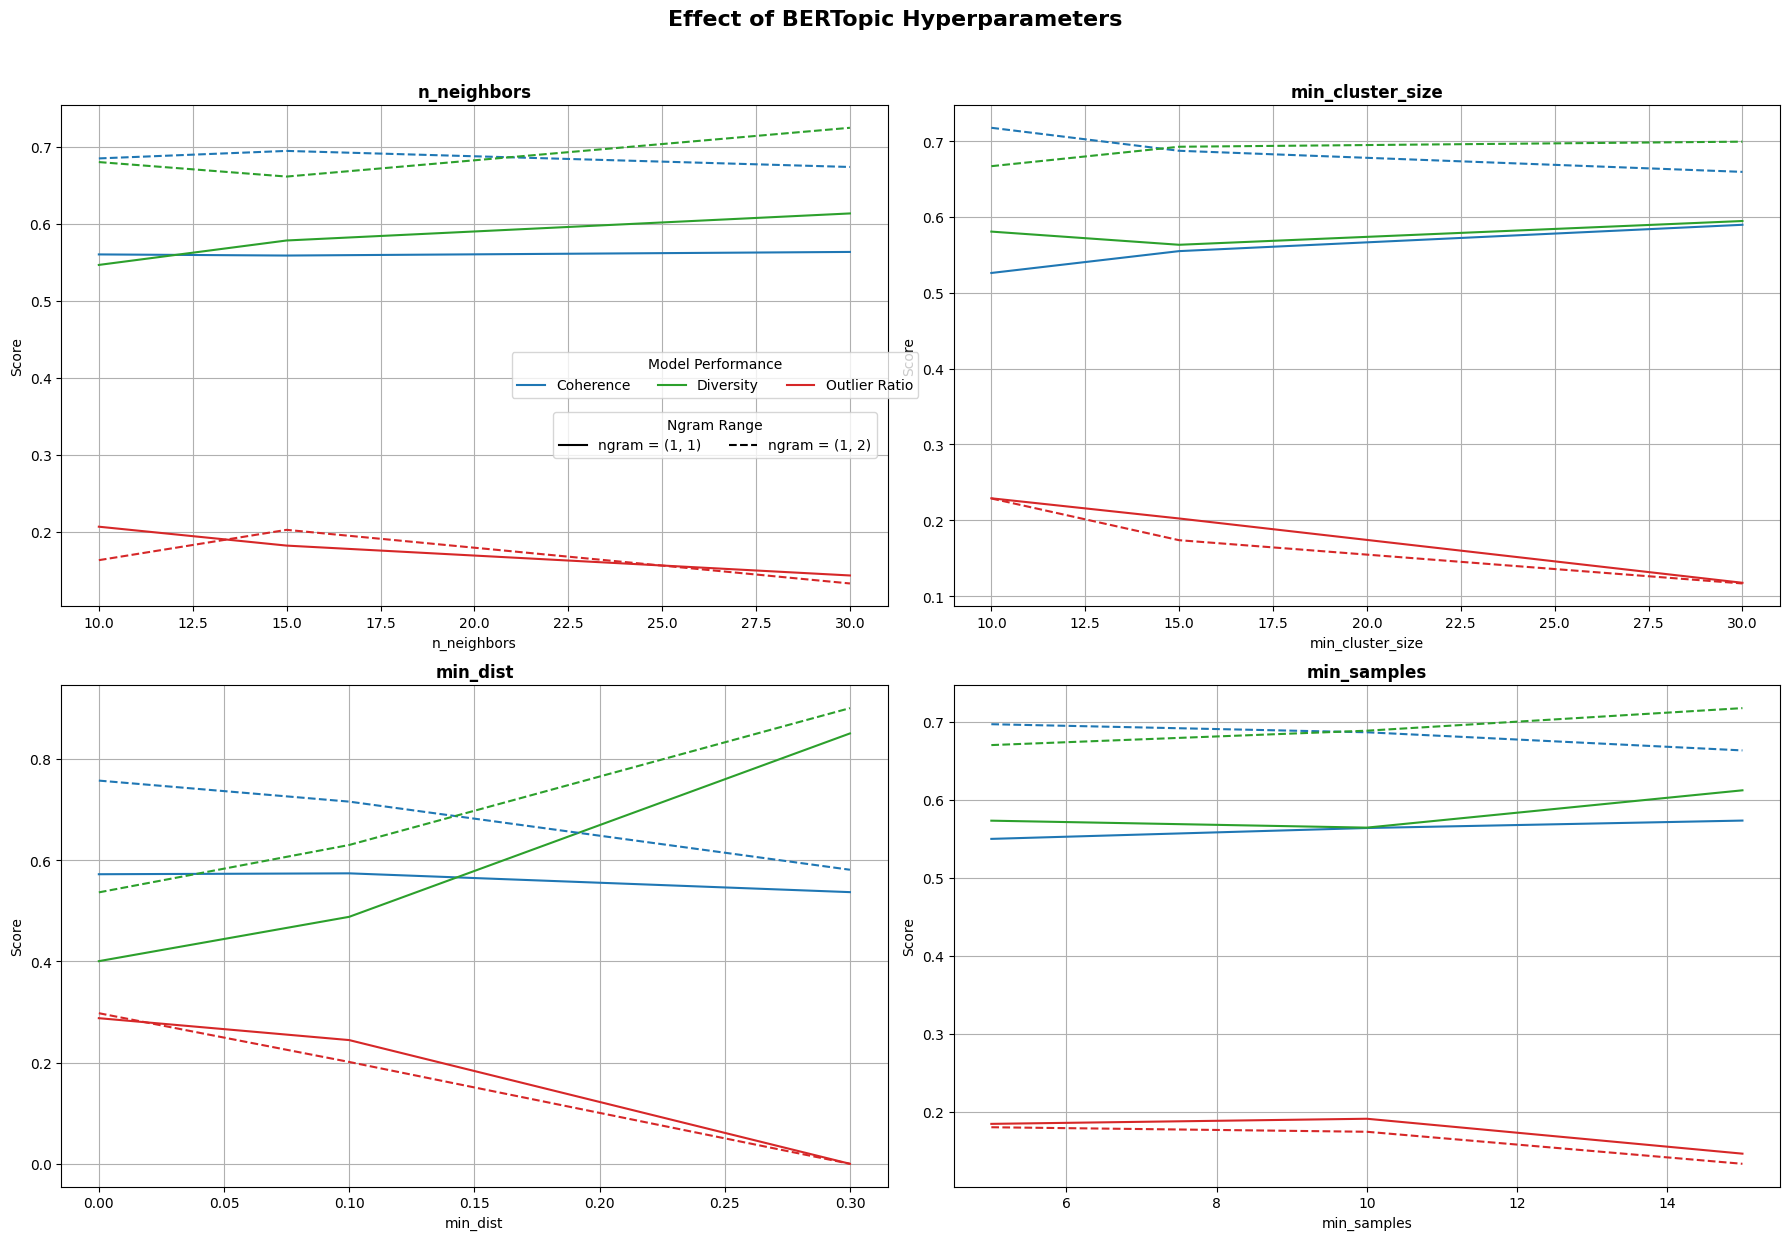

In [46]:
plot_all_hyperparams(df_results)